## Importing Libraries
- NumPy and Pandas are used for numerical operations and data manipulation, respectively.
- Matplotlib and Seaborn are used for visualization.
- sklearn provides tools for machine learning, including datasets, model selection, and evaluation metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

## Load the Data
- The Iris dataset contains 150 samples of iris flowers, with four features: sepal length, sepal width, petal length, and petal width. The target variable is the species of the iris flower (Setosa, Versicolor, or Virginica).

In [15]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target  # Target labels

# Create a DataFrame for better visualization
iris_df = pd.DataFrame(data=X, columns=iris.feature_names)
#print(iris_df.head())
#print(iris_df.describe())
#iris_df.info()
#print(iris.DESCR)
iris_df['species'] = y


## Data Visualization
- The pairplot function from Seaborn creates scatter plots for each pair of features, colored by species. This helps in visualizing the separability of different classes.

In [18]:
# Visualize the data
#sns.pairplot(iris_df, hue='species', palette='deep')
#plt.title("Iris Dataset Pairplot")
#plt.show()

## Split the Data
- The train_test_split function splits the dataset into training (80%) and testing (20%) subsets, ensuring that our model can be evaluated on unseen data.

In [20]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train the SVM Model
- Here, we create an instance of the SVM classifier with a linear kernel and fit it to the training data. The linear kernel is appropriate because the Iris dataset is generally linearly separable.

In [21]:
# Create an SVM classifier
svm_model = SVC(kernel='linear')  # Using a linear kernel
#svm_model = SVC(kernel='sigmoid')
#svm_model = SVC(kernel='poly', degree=3, coef0=1)
#svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Make Predictions
- The predict method generates predictions for the test data based on the model trained in the previous step.

In [23]:
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

## Evaluate the Model
- The confusion matrix shows the number of true vs. predicted classifications, allowing us to see where the model makes mistakes.
The classification report includes precision, recall, and F1-score, providing a comprehensive view of the model's performance.

In [24]:
# Evaluate the model
print("Confusion Matrix: Train Data")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))
print("============================================================================")
# Evaluate the model
print("Confusion Matrix: Test Data")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Confusion Matrix: Train Data
[[40  0  0]
 [ 0 39  2]
 [ 0  1 38]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.97      0.95      0.96        41
           2       0.95      0.97      0.96        39

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120

Confusion Matrix: Test Data
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Visualizing the Decision Boundary
- We visualize the decision boundary of the SVM model using just the first two features (sepal length and sepal width).
- A mesh grid is created to plot the decision boundary, and the predicted classes are shown with colors.

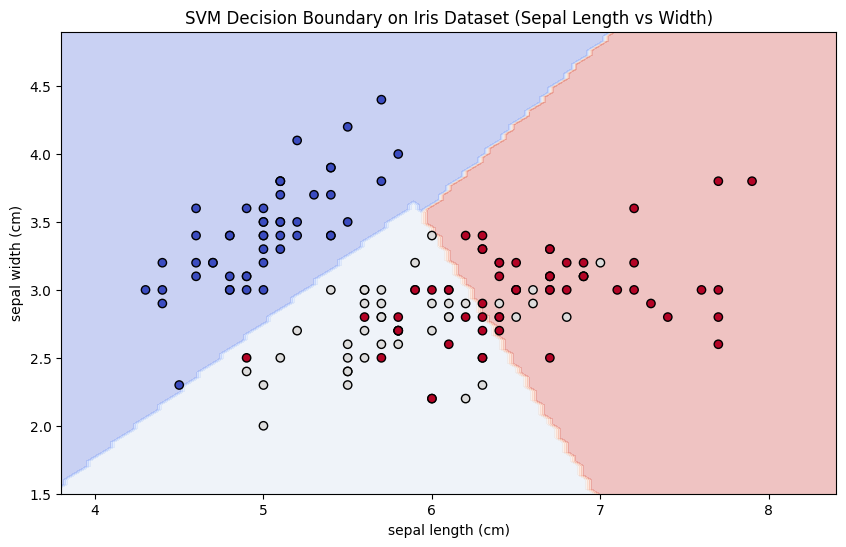

In [25]:
# Visualize decision boundaries (using only the first two features for simplicity)
X_2D = iris.data[:, :2]  # Use sepal length and width
y_2D = iris.target

svm_model_2D = SVC(kernel='linear')
svm_model_2D.fit(X_2D, y_2D)

# Create a mesh grid
xx, yy = np.meshgrid(np.linspace(X_2D[:, 0].min() - 0.5, X_2D[:, 0].max() + 0.5, 100),
                     np.linspace(X_2D[:, 1].min() - 0.5, X_2D[:, 1].max() + 0.5, 100))
Z = svm_model_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y_2D, edgecolors='k', cmap='coolwarm')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("SVM Decision Boundary on Iris Dataset (Sepal Length vs Width)")
plt.show()


## Trying different kernels
#### Mesh Grid Creation:

- A mesh grid is created to visualize the decision boundaries.

#### Subplots:

- A 1x3 subplot is created for the three kernels: linear, polynomial, and RBF.
- Each SVM model is trained and its decision boundary is plotted on the respective axes.

#### Plotting:

- Decision boundaries are plotted using contourf, and the data points are overlaid with scatter plots.

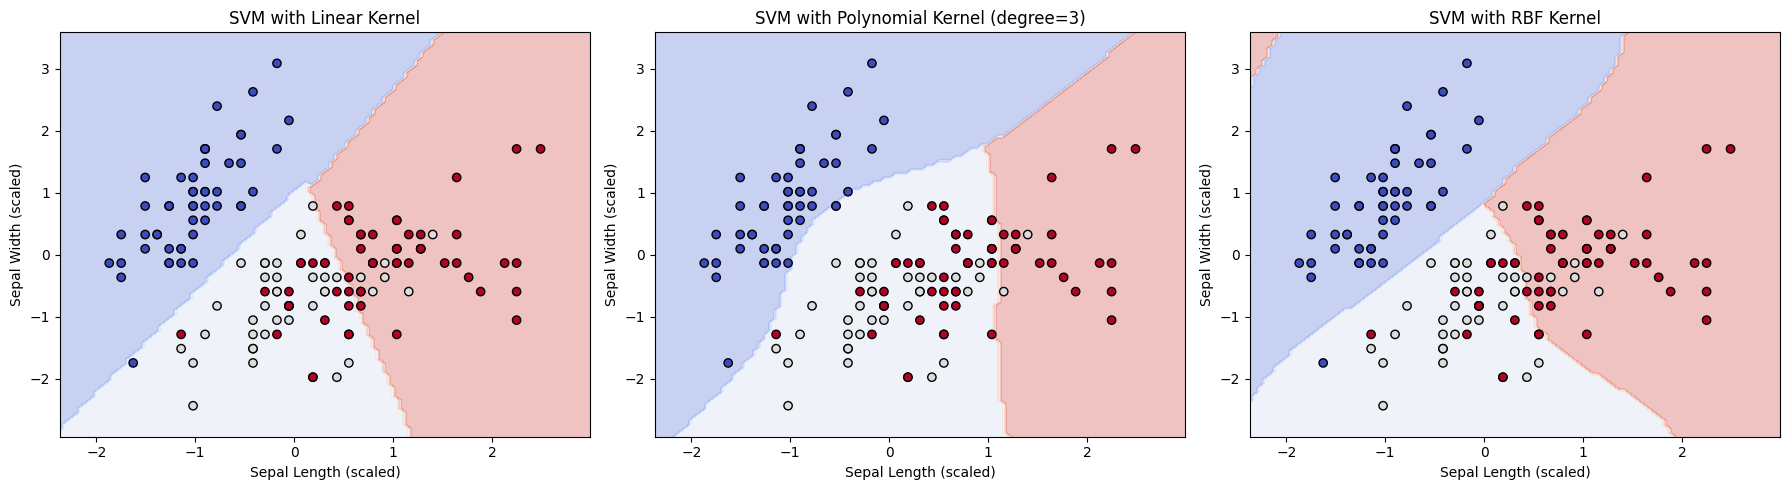

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset and use only the first two features for visualization
iris = datasets.load_iris()
X = iris.data[:, :2]  # Using only sepal length and sepal width
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a mesh grid for plotting
xx, yy = np.meshgrid(np.linspace(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5, 100),
                     np.linspace(X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5, 100))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define kernel types and their titles
kernels = ['linear', 'poly', 'rbf']
titles = ['SVM with Linear Kernel', 'SVM with Polynomial Kernel (degree=3)', 'SVM with RBF Kernel']

# Train SVM with different kernels and plot decision boundaries
for ax, kernel, title in zip(axes, kernels, titles):
    svm_model = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 3)  # Set degree for polynomial kernel
    svm_model.fit(X_scaled, y)

    # Predict on the mesh grid
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    ax.set_title(title)
    ax.set_xlabel('Sepal Length (scaled)')
    ax.set_ylabel('Sepal Width (scaled)')

plt.tight_layout()
plt.show()


## Tuning Parameter C
- Kernel Type: The kernel is fixed to RBF.
- The model is trained with three different values for C (1, 10, and 100).
- Visualization: Each subplot will show the decision boundary for the corresponding value of C

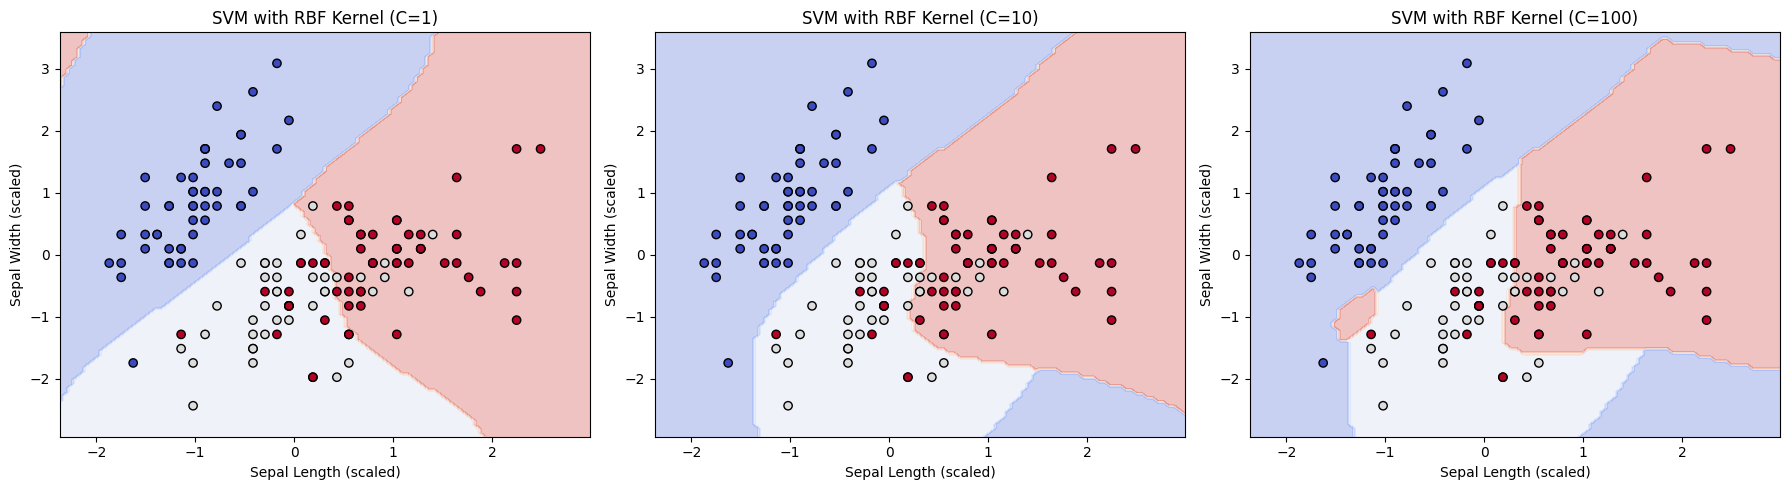

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset and use only the first two features for visualization
iris = datasets.load_iris()
X = iris.data[:, :2]  # Using only sepal length and sepal width
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a mesh grid for plotting
xx, yy = np.meshgrid(np.linspace(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5, 100),
                     np.linspace(X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5, 100))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define C values
C_values = [1, 10, 100]
titles = ['SVM with RBF Kernel (C=1)', 'SVM with RBF Kernel (C=10)', 'SVM with RBF Kernel (C=100)']

# Train SVM with RBF kernel for different C values and plot decision boundaries
for ax, C, title in zip(axes, C_values, titles):
    svm_model = SVC(kernel='rbf', C=C)
    svm_model.fit(X_scaled, y)

    # Predict on the mesh grid
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    ax.set_title(title)
    ax.set_xlabel('Sepal Length (scaled)')
    ax.set_ylabel('Sepal Width (scaled)')

plt.tight_layout()
plt.show()
